Breakdown:

potentials.py

solver.py (The main function)

Then, a fourth file, main_app.py, will bring everything together, handle the MediaPipe input, and plot the results.

Ideas:
 - A clean, modular solver that works for **custom 1D potentials**.

 - Later: **GPU acceleration**, nicer **UI**, maybe interactive widgets. (FUTURE)

 Technical / numerical TODO:

 - Rigorous boundary-condition (BC) enforcement(Dirichlet for infinite well)

 - Orthonormality diagnostic plots (implemented, but can be refined)

 - Convergence analysis

   - e.g. compare $N = 500$ vs $N = 2000$ to see how the discrete operator $\mathbf{D2}$ behaves

 - Analytic solution benchmarking

   - For the infinite square well: compare $E_n$ to

     $$

     E_n = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

     $$
 - QM Solve Benchmarking 

 - Documentation + modular design


---

## 0. Quantum picture: what am I actually solving?


In the postulate language of quantum mechanics:

- A **state** of the particle is described by a wavefunction $\Psi(x)$ 
  (or a vector $|\Psi\rangle$ in a Hilbert space).

- **Observables** (like energy) are represented by **Hermitian operators**.
  
  For a particle in 1D with potential $$V(x)$$, the Hamiltonian operator is

  $$
  \hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x).
  $$

- The **energy eigenstates** are solutions of

  $$
  \hat{H}\,\psi_n(x) = E_n \,\psi_n(x),
  $$

  with boundary conditions and normalization: $\int |\psi_n(x)|^2 dx = 1.$

Physically:

- Each $\psi_n(x)$ is a **stationary state**: if the system is prepared in $\psi_n$, the probability density $|\psi_n(x,t)|^2$ is independent of time (it only picks up a phase $e^{-iE_n t/\hbar}$).

- The energies $E_n$ are the possible outcomes of a precise **energy measurement**.

- A general state can be expanded as

  $$
  \Psi(x,0) = \sum_n c_n \psi_n(x),
  $$

A numerical solver is really a machine that takes a **chosen potential** $$V(x)$$ and returns:

- The discrete spectrum $$\{E_n\}$$ (energy levels for that potential).
- The corresponding eigenfunctions $$\psi_n(x)$$ (stationary states).

Once I have those, I can in principle build **any** time-dependent solution by choosing coefficients $$c_n$$.


---


### 2.3.1 Physical interpretation: standing waves, nodes, and quantization

The infinite well is a quantum version of a **string fixed at both ends**:

- The boundary conditions $$\Psi(0) = \Psi(a) = 0$$ only allow certain “standing wave” shapes.
- Those shapes are exactly

  $$
  \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n\pi x}{a}\right),
  $$

  with integer $$n = 1,2,3,\dots$$

Each $$n$$ has:

- $n-1$ internal **nodes** (points where $\Psi_n(x) = 0$ inside the well).
- Increasing **curvature** of the wavefunction, which corresponds to higher kinetic energy.

This is why the energies scale like

$$
E_n \propto n^2.
$$

The key physics point:

- The **discreteness** of the spectrum (energy quantization) is not put in by hand.
- It **emerges** from:
  - the wave nature of the particle, and
  - the boundary conditions (particle confined in a finite region).

My numerical solver is reproducing that spectrum purely from the operator

$$
\hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x)
$$

and the boundary conditions encoded in the matrix.
---


On the grid, an integral becomes a sum:

$$
\int f(x)\,dx \approx \sum_i f(x_i)\,\Delta x.
$$

So for a normalized eigenstate $$\psi_n(x)$$:

- Position expectation value:

  $$
  \langle x \rangle_n \approx \sum_i x_i\,|\psi_n(x_i)|^2\,\Delta x.
  $$

- Position variance:

  $$
  \Delta x_n^2 = \langle x^2 \rangle_n - \langle x \rangle_n^2.
  $$



### 3.5 Operator viewpoint: matrix = Hamiltonian in a finite basis

Conceptually, what I’ve done is:

- Start from the abstract operator equation

  $$
  \hat{H}|\psi_n\rangle = E_n |\psi_n\rangle,
  $$

- Choose the **position basis** sampled on a grid
  $$\{|x_1\rangle, |x_2\rangle, \dots, |x_{N-1}\rangle\},$$
- Represent $$\hat{H}$$ as an $$N\times N$$ **matrix** in that basis using finite differences for the kinetic term
  and a diagonal matrix for $V(x)$.

Because $\hat{H}$ is Hermitian (and my discrete approximation respects that symmetry), the matrix is:

- Real symmetric,
- Has **real** eigenvalues,
- And its eigenvectors form an **orthonormal basis** of the grid space.

This is exactly what I see in the overlap matrix: numerically, it is very close to the identity.



 - If $V(x) = 2$ (some constant), then placing a particle there means:

   - The particle "sits" at potential energy 2 (in whatever units I'm using).

   - To move around with total energy $E$, its kinetic energy is $K = E - V(x)$.

   - So if $V$ is larger, the kinetic energy available is smaller for the same $E$.



 - Intuition:

   - $V(x) = 0$ → flat ground

   - $V(x) = 2$ → you are walking on a slope of "height 2"

   - It's easier to move where $V(x)$ is low than where $V(x)$ is high.



 - If $V(x) = \infty$ in some region, then:

   - A particle would need **infinite total energy** to enter that region.

   - In quantum mechanics, this is enforced by making the wavefunction **exactly zero**

     there: the particle simply **cannot exist** in that region.



 This is exactly how the **infinite square well** is defined.

 ### 2.1 Time-Independent Schrödinger Equation (TISE)



 The time-independent Schrödinger equation is



 $$

 H \Psi(x) = E \Psi(x)

 $$



 with the Hamiltonian



 $$

 H = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} + V(x)

 $$



 For the infinite well region (where $V(x) = 0$), the TISE reduces to:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2 \Psi}{dx^2} = E \Psi

 $$

 ### 2.2 Boundary conditions and physical constraints



 We enforce some conditions on the wavefunction based on physical requirements:



 - Dirichlet boundary conditions:

   $$

   \Psi(0) = \Psi(a) = 0

   $$



   Reason (continuity argument):

   - Schrödinger's equation requires $\Psi(x)$ to be **continuous**.

   - If $\Psi(x)$ had a jump, its second derivative would involve something like a delta function,

     which would blow up the kinetic energy term.

   - Outside the well, where $V(x) = \infty$, the wavefunction must vanish:

     $$

     \Psi(0^-) = 0, \quad \Psi(a^+) = 0

     $$

   - Continuity then implies

     $$

     \Psi(0^+) = 0, \quad \Psi(a^-) = 0

     $$

     so we simply write $\Psi(0) = \Psi(a)=0$.



 - Normalization:

   $$

   \int_{-\infty}^{\infty} |\Psi(x)|^2 \, dx = 1

   $$

   In practice, for the infinite well, this is

   $$

   \int_0^a |\Psi(x)|^2 \, dx = 1.

   $$



 - Probabilistic interpretation:

   - $|\Psi(x)|^2 \, dx$ is the probability of finding the particle between $x$ and $x + dx$.

 ### 2.3 Known analytic solutions (for checking the numerics later)



 For the infinite square well, the analytic solutions are:



 - Wavefunctions:

   $$

   \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n \pi x}{a}\right), \quad n = 1, 2, 3, \dots

   $$



 - Energy levels:

   $$

   E_n = \frac{\hbar^2 \pi^2 n^2}{2 m a^2}

   $$



 Later in this notebook, I compare the **numerical eigenvalues** to these $E_n$ as a benchmark.

 ## 3. Discretizing the TISE



 To turn the differential equation into something a computer can solve, I:



 - Break the continuous space into small chunks.

 - Use a finite-difference approximation for derivatives.

 - Build a matrix that mimics the second derivative.

 - Solve the resulting **matrix eigenvalue problem**.



 Let me formalize that.

 ### 3.1 Discretizing the derivative



 We start from the usual definition of the derivative:



 $$

 f'(x_i) = \lim_{\Delta x \to 0} \frac{f(x_i + \Delta x) - f(x_i)}{\Delta x}

 $$



 In the code, I *do not* send $\Delta x$ to 0. Instead:



 - I choose a **fixed** grid spacing $\Delta x$.

 - I approximate the derivative using finite differences.



 For the **first derivative**, a forward-difference formula is



 $$

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}.

 $$



 This is called the **forward difference** operator. There are also backward and central differences,

 but for the second derivative we usually like the central difference.

 ### 3.2 Building the second derivative $f''(x_i)$



 Because $\Delta x$ is constant, and derivatives are linear, we can say:



 $$

 f''(x_i) \approx \frac{f'(x_{i+1}) - f'(x_i)}{\Delta x}.

 $$



 Now plug in the finite-difference expressions for $f'$:



 $$

 f'(x_{i+1}) \approx \frac{f(x_{i+2}) - f(x_{i+1})}{\Delta x}, \quad

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 $$



 so



 $$

 f''(x_i) \approx

 \frac{

 \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 -

 \frac{f(x_i) - f(x_{i-1})}{\Delta x}

 }

 {\Delta x}

 =

 \frac{f(x_{i+1}) - 2 f(x_i) + f(x_{i-1})}{\Delta x^2}.

 $$



 This is the standard **central difference** formula for the second derivative.



 It is exactly what I will use to approximate the operator $\frac{d^2}{dx^2}$ on a grid.

 ### 3.3 Writing the second derivative as a matrix



 Let the grid points be $x_1, x_2, x_3, x_4, \dots$ and the function values be



 $$

 f(x_i) \rightarrow

 f_i =

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$



 Then the central-difference formula for the second derivative gives:



 $$

 \begin{cases}

 f''_1 = \dfrac{f_2 - 2 f_1 + f_0}{(\Delta x)^2}, \\

 f''_2 = \dfrac{f_3 - 2 f_2 + f_1}{(\Delta x)^2}, \\

 f''_3 = \dfrac{f_4 - 2 f_3 + f_2}{(\Delta x)^2}, \\

 \vdots

 \end{cases}

 $$



 The pattern is a stencil $[1, -2, 1]$ sweeping across the vector.



 In matrix form:



 $$

 \frac{d^2}{dx^2} f(x_i) \approx f''(x_i)

 = \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$

 ### 3.4 Schrödinger equation in matrix form



 Starting from



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi(x) + V(x) \Psi(x) = E \Psi(x),

 $$



 when we discretize, the kinetic term becomes:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}

 \;\;\longrightarrow\;\;

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}.

 $$



 So the matrix version of the TISE is



 $$

 H \Psi = E \Psi

 $$



 with



 $$

 H =

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 + \text{diag}\big(V(x_1), V(x_2), \dots \big).

 $$



 Note:



 - This matrix acts on the **internal grid points** from $\Psi_1$ to $\Psi_{N-1}$.

 - The boundary values $\Psi_0$ and $\Psi_N$ are fixed by the **Dirichlet BC**:

   $$

   \Psi_0 = \Psi_N = 0.

   $$

 - So the computer only solves for the interior and the BC is enforced by construction.

 With this theory in place, I now build the actual code.

Summary Table, 

🔍 Visual Behavior Summary
Region	Classical?	
𝐸
E vs 
𝑉
V	Wavefunction Shape	Physical Meaning
Inside well	Allowed	
𝐸
>
𝑉
E>V	Oscillatory	Free motion
In barrier	Forbidden	
𝐸
<
𝑉
E<V	Exponential decay	Tunneling
Far from finite well	Forbidden	
𝐸
<
𝑉
E<V	Decays to 0	Bound state localization
Above barrier	Allowed	
𝐸
>
𝑉
max
E>V
max
	​

	Oscillatory everywhere	Free particle scattering



⭐ What Features Should We Expect in Simulations?

Your solver will vividly show all major quantum phenomena:

Feature	Why it appears
Quantized energy levels	Only certain waves fit boundary conditions
Increasing nodes with increasing energy	Higher momentum → shorter wavelength
Exponential decay outside well	
𝜓
ψ suppressed when 
𝐸
<
𝑉
E<V
Tunneling across barriers	Wavefunction doesn’t vanish instantly
Symmetry (even/odd states)	Symmetric potentials enforce wave parity
Energy splitting in double wells	Coupling through tunneling mixes states

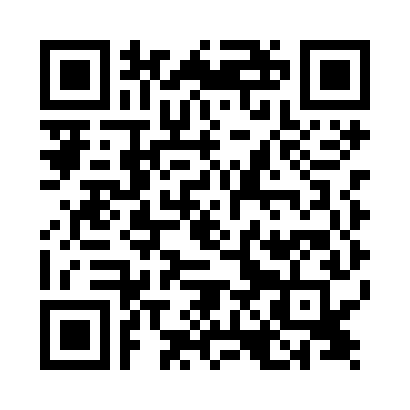

In [1]:
from functions import show_QR
url = "https://huggingface.co/spaces/AhiBucket/Hand-wave?logs=container"
show_QR(url)

### psi_solve


In [1]:
# psi_solve2/ModulatedPresentation.ipynb

### constants
```python 
constants.py
```

In [3]:
x_min = -10
x_max = 10
N = 2000


from functions import make_grid

x,dx,x_internal = make_grid(x_min=x_min,x_max=x_max,N_GRID=N)


### Potentials

```python 
potentials.py
```

In [4]:
from functions import inf_sqaure_well,finite_square_well,gaussian_well,constant,harmonic

 ### Play Ground for $V(x)$



 Here I choose which potential to use. For now, I will default to the **infinite square well**.



 - I can later uncomment and experiment with:

   - harmonic oscillator + walls,

   - double wells,

   - Gaussian wells,

   - barriers inside wells, etc.

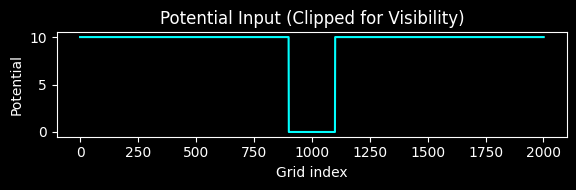

In [6]:
import numpy as np
L = 2
#V = inf_sqaure_well(x,-100,100)

V = inf_sqaure_well(x,lower_bound=-L/2,upper_bound=+L/2)

#V = harmonic(x,k=5)

# --- 3. USER PLAYGROUND (Mix and Match Here) ---

# EXAMPLE 1: Half-Harmonic Oscillator (Wall on left, parabola on right)
# V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

# EXAMPLE 2: A Harmonic Oscillator with a Barrier in the middle
#V = harmonic(x, k=5) + finite_barrier(x, center=L/2, width=0.5, height=50)

# EXAMPLE 3: Double Well (Two Gaussians)
# V = gaussian_well(x, center=3) + gaussian_well(x, center=7)

# Finite wall showing QM TUnneling
# V = finite_square_well(x,-10,10,0.01)

# Let's run Example 1:
#V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

#V = finite_square_well(x,0,10,0.1)


from functions import plot_V

plot_V(V);



# Error with plot Axis...

In [7]:
hbar = 1
m = 1

from functions import kinetic_operator
T = kinetic_operator(N, dx, hbar=hbar,m=m)

# Show Kinetic operator on functions 


 For an $N \times N$ matrix (e.g. $4 \times 4$ toy example), the pattern is:



 $$

 \begin{bmatrix}

 1 & 1 & 0 & 0  \\

 1 & 2 & 2 & 0  \\

 0 & 2 & 3 & 3  \\

 0 & 0 & 3 & 4  \\

 \end{bmatrix}

 $$



 - Main diagonal: $N$ elements

 - Off diagonals: each has $N-1$ elements



 Here, my actual matrix is the finite-difference approximation to $\dfrac{d^2}{dx^2}$,

 and I then build the Hamiltonian:



 $$

 - \frac{\hbar^2}{2m} \left( \frac{d^2}{dx^2} \right) \Psi = E \Psi

 $$



 turns into



 $$

 H \Psi = E \Psi,

 $$



 where $H$ is built from $D2$ plus the potential.

### Solve

``` python 
solver.py 
```

 The integral



 $$

 \int_{x_1}^{x_N} f(x)\,dx \approx \sum_{i=1}^{N} f(x_i)\,\Delta x

 $$



 is implemented as a Riemann sum on the grid.

In [8]:
from functions import solve

#V = finite_square_well(x,-10,10,0.01)


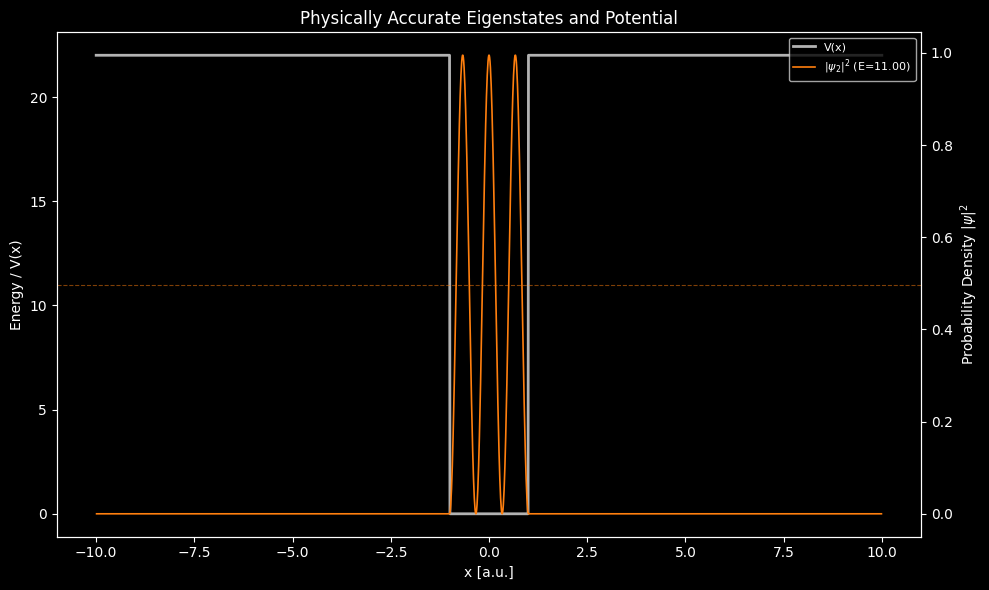

In [9]:
from functions import plot_alive
E, psi = solve(T, V, dx)
plot_alive(E, psi, V, x, no=2);


Wall height is only 0.01 Hartree, which is extremely low! Looking at image, the energy level E ≈ 0.06 is much higher than the potential barrier (0.01). This means:

The particle has MORE energy than the barrier height
It's not a bound state 
The wavefunction should oscillate everywhere because E > V everywhere outside the well
The Physics
For exponential decay in classically forbidden regions, you need:

E < V in those regions
For a finite square well, bound states only exist when E < V_barrier



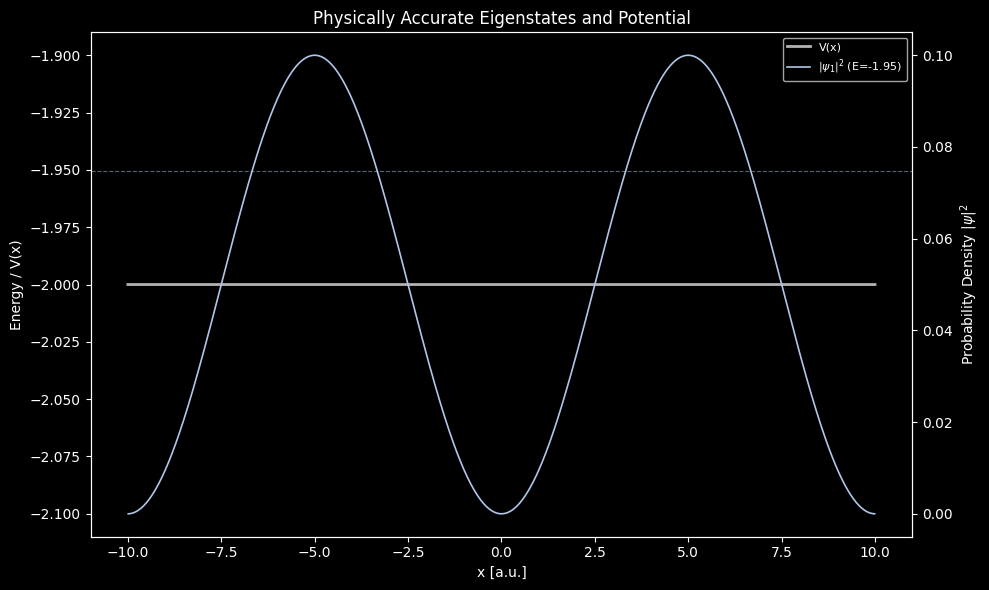

In [10]:
V = finite_square_well(x, -10, 10, 2)  # Strong confinement
E, psi = solve(T, V, dx)
plot_alive(E, psi, V, x, no=1);
 


This will create bound states where E < V_barrier, and you'll see the characteristic exponential decay in the classically forbidden regions outside the well.

In [36]:
# Debug 2
bool(0)
print(E)
E.shape
E[-1]

[1.11658063e-02 4.46374645e-02 1.00337006e-01 ... 3.40316668e+01
 3.40319227e+01 3.40319227e+01]


34.03192269674214

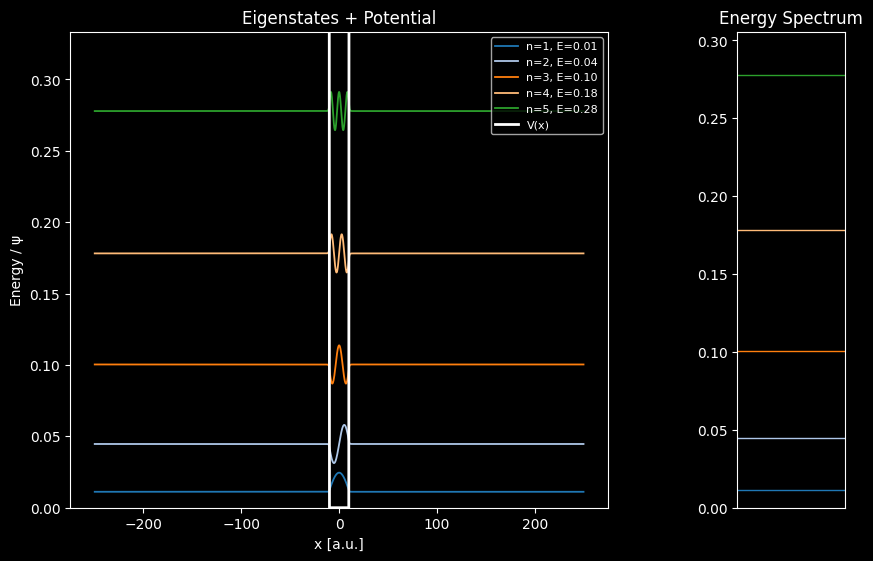

In [37]:
#%matplotlib widget
# Inaccurate Plot for intution (Like the Textbook)

from functions import plot_dead

plot_dead(E, psi, V, x, nos=5);

 ## 4. How do I trust the computer?



 So far:



 - I constructed a Hamiltonian matrix.

 - I asked the computer for its eigenvalues and eigenvectors.

 - I enforced boundary conditions by construction.



 But how do I know these eigenvectors are actually good **approximations to true eigenstates**?



 Two big checks:



 1. **Orthonormality** (linear algebra + normalization)

 2. **Analytic benchmarking** (compare to known formulas)



 ### 4.1 Orthonormality



 If I have two different eigenstates, $\psi_m$ and $\psi_n$ (with $m \neq n$), their inner product must be zero:



 $$

 \langle \psi_m | \psi_n \rangle = 0.

 $$



 This is called **orthogonality**.

 If $m = n$, then the inner product is 1 (if I normalize them properly):



 $$

 \langle \psi_n | \psi_n \rangle = 1.

 $$



 So the **overlap matrix** or **orthonormality matrix** is:



 $$

 \mathbf{S}_{mn} = \langle \psi_m | \psi_n \rangle

 = \int \psi_m^*(x) \psi_n(x) \, dx

 $$



 and in discrete form on the grid:



 $$

 \mathbf{S}_{mn} \approx \sum_i \psi_m(x_i) \psi_n(x_i) \, \Delta x.

 $$



 For properly normalized eigenstates of a Hermitian Hamiltonian, $\mathbf{S}$ should be **the identity matrix**:

 - Diagonal = 1

 - Off-diagonal = 0 (up to small numerical errors)

In [12]:
from functions import check_ortho,show_matrix

overlap_matrix = check_ortho(psi,dx,num_states_to_check=5)

show_matrix(overlap_matrix,how="normal")




--- Orthonormality Check (First 5 states) ---
Overlap Matrix should approximate the Identity Matrix:
[[ 1.00000000e+00  0.00000000e+00 -1.24837671e-16  2.77417048e-17
  -2.94755613e-16]
 [ 0.00000000e+00  1.00000000e+00  1.10966819e-16 -5.43455662e-16
  -2.28869064e-16]
 [-1.24837671e-16  1.10966819e-16  1.00000000e+00 -2.77417048e-16
  -3.71045301e-16]]


In [13]:

show_matrix(overlap_matrix,how="round",round_value=10)


[[ 1.  0. -0.  0. -0.]
 [ 0.  1.  0. -0. -0.]
 [-0.  0.  1. -0. -0.]
 [ 0. -0. -0.  1. -0.]
 [-0. -0. -0. -0.  1.]]


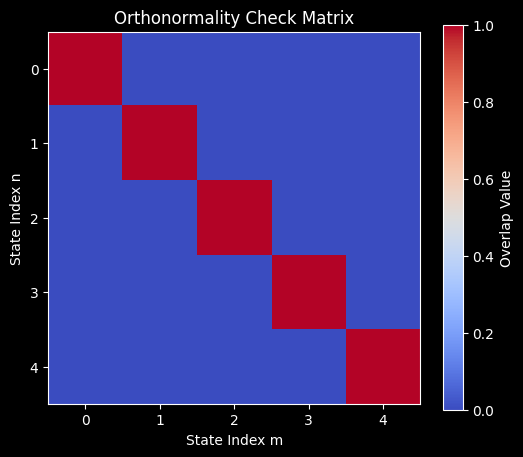

In [38]:
show_matrix(overlap_matrix,how="plot",round_value=10)


 ## 5. Analytical tests (benchmarking)



 Orthonormality tells me the eigenvectors make sense **as a basis**, but I still want to know:



 > Are these the *correct* eigenstates for **this** potential?



 For that, I compare:



 - The **numerical** energy levels from the matrix diagonalization.

 - The **analytic** formulas I already know:

   - Infinite square well energy spectrum.

   - (Optionally) harmonic oscillator spectrum when I switch potential.



 ---



 ### 5.1 Indexing remark



 - In physics, the ground state is $E(n = 1)$ for the infinite square well.

 - In Python, array indices start at 0.



 So:



 - Physically: $n = 1, 2, 3, \dots$

 - In code: `i = 0, 1, 2, ...` corresponds to $n = i + 1$.



 This mismatch is annoying but standard in programming.

 ### 5.2 Infinite square well energies



 The analytic formula:



 $$

 E_{n}^{\text{analytic}} = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

 $$



 (Here $L$ is the well width.)

In [15]:
from functions import check_ISW_analytic


check_ISW_analytic(E,L,hbar=1.0, m=1.0, max_levels=6)


### ENERGY BENCHMARK: Infinite Square Well ###
Well boundaries: x = [500, 10], Width L = -490
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 1 | 0.000021   | 0.011166    | 54226.5967% |
| 2 | 0.000082   | 0.044637    | 54195.2624% |
| 3 | 0.000185   | 0.100337    | 54142.6673% |
| 4 | 0.000329   | 0.178132    | 54068.2127% |
| 5 | 0.000514   | 0.277832    | 53970.9688% |
| 6 | 0.000740   | 0.399179    | 53849.5563% |
-------------------------------------------------------


(array([2.05531120e-05, 8.22124482e-05, 1.84978008e-04, 3.28849793e-04,
        5.13827801e-04, 7.39912033e-04]),
 array([0.01116581, 0.04463746, 0.10033701, 0.17813206, 0.27783167,
        0.39917926]))

## Convergence Test



In [16]:
# COnvergence Test

 ### 5.3 Harmonic oscillator benchmark



 When I switch $V(x)$ to a harmonic oscillator $V(x) = \tfrac{1}{2} k (x-x_0)^2$ and run the solver:



 - The analytic energy levels are

   $$

   E_n^{\text{HO}} = \left(n + \frac{1}{2}\right) \hbar \omega

   $$

   where $\omega = \sqrt{k/m}$ and $n = 0, 1, 2, \dots$.



 - I can compare the numerical $E_n$ to those values.

 - This is a good **second** test after the infinite square well.

In [17]:
# Assuming Last_k_value, hbar, m, E, and CHECK_N are available
from functions import check_harmonic_analytic
check_harmonic_analytic(E,max_levels=6)

from functions import harmonic

check_ISW_analytic(E,)


### ENERGY BENCHMARK: Harmonic Oscillator ###
Spring constant k = 5, Center = 0.0, omega = 2.2361
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 0 | 1.118034   | 0.011166    | 99.0013% |
| 1 | 3.354102   | 0.044637    | 98.6692% |
| 2 | 5.590170   | 0.100337    | 98.2051% |
| 3 | 7.826238   | 0.178132    | 97.7239% |
| 4 | 10.062306  | 0.277832    | 97.2389% |
| 5 | 12.298374  | 0.399179    | 96.7542% |
-------------------------------------------------------

### ENERGY BENCHMARK: Infinite Square Well ###
Well boundaries: x = [-10, 10], Width L = 20
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 1 | 0.012337   | 0.011166    | 9.4934 % |
| 2 | 0.049348   | 0.044637    | 9.5456 % |
| 3 | 0.111033   | 0.100337    | 9.6332 % |
| 4 | 0.197392   | 0.178132    | 9.7572 % |
| 

(array([0.01233701, 0.04934802, 0.11103305, 0.19739209, 0.30842514,
        0.4441322 ]),
 array([0.01116581, 0.04463746, 0.10033701, 0.17813206, 0.27783167,
        0.39917926]))

In [18]:

import cv2
import mediapipe as mp
# Initialize Grid
# CORRECT CODE
x_full, dx, x_solver = make_grid(L=L, N=N_GRID)

# Build Kinetic Energy Matrix
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)

print("Physics Engine Ready.")
print(f"Grid: {N_GRID} points over L={L}")

Physics Engine Ready.
Grid: 2000 points over L=500


In [19]:

# 1. Imports (Make sure these are available in your environment)
import cv2
import numpy as np
import time
import math
import mediapipe as mp 
from IPython.display import display, Image, clear_output
from scipy.interpolate import interp1d # Needed for later potential resizing


from functions import display_params



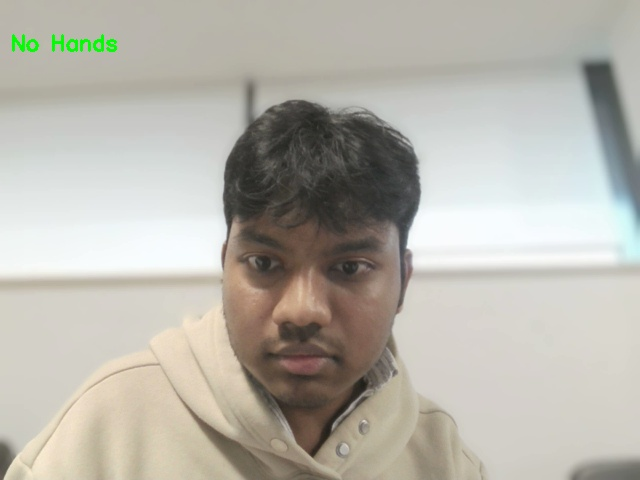

Time limit of 30 seconds reached.
Potential capture failed or was aborted.
Error: Run the Camera Input cell first to get V_raw_input!


TypeError: cannot unpack non-iterable NoneType object

In [20]:

# 4. Execute Capture
print("Starting camera stream...")
# Assuming A_MIN and A_MAX are defined or hardcoded.
A_MIN = 0
A_MAX = 100 

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.7)
drawer = mp.solutions.drawing_utils


def cheese(tune, A_MIN, A_MAX, mode='wait'):
    import time
    import cv2
    from IPython.display import display, Image, clear_output

    
    # Copy relevant constants from the file for local scope
    THUMB_TIP_ID = 4
    INDEX_TIP_ID = 8
    REQUIRED_STABLE_FRAMES = 45
    MOVEMENT_THRESHOLD = 0.015
    PLOT_CEILING_A = 10.0
    EPS = 1e-9
    
    D_MIN = 0.001
    D_MAX = 0.2
    D_RANGE = D_MAX - D_MIN
    A_RANGE = A_MAX - A_MIN
    SLOPE = -A_RANGE / D_RANGE
    INTERCEPT = A_MAX - SLOPE * D_MIN
    # End of copied constants
    
    cap = cv2.VideoCapture(0)
    captured_V = None
    
    if not cap.isOpened():
        print("Error: Could not open video stream. Check permissions or camera index.")
        return None

    stability_counter = 0
    prev_landmarks = []
    
    start_time = time.time()
    MAX_RUN_TIME_SECONDS = 30 
    
    print("Controls: HOLD STILL to capture, or wait for the time limit to exit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = hands.process(rgb)

        pot_profile = None
        mode_msg = "No Hands"
        params_to_display = []
        current_landmarks_flat = []

        # --- LANDMARK AND POTENTIAL LOGIC (Skipped for brevity, assume this is correct) ---
        if res.multi_hand_landmarks:
            for hand_lms in res.multi_hand_landmarks:
                for lm in hand_lms.landmark:
                    current_landmarks_flat.extend([lm.x, lm.y])
            for lm in res.multi_hand_landmarks:
                drawer.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
            
            # TWO HANDS (Square Well)
            if len(res.multi_hand_landmarks) >= 2:
                mode_msg = "Mode: Square Well (Auto-Centered)"
                x_coords = [lm.landmark[INDEX_TIP_ID].x * w for lm in res.multi_hand_landmarks]
                x_coords.sort()
                xL_hand, xR_hand = int(x_coords[0]), int(x_coords[1])
                cv2.line(frame, (xL_hand, 0), (xL_hand, h), (0, 255, 255), 2)
                cv2.line(frame, (xR_hand, 0), (xR_hand, h), (0, 255, 255), 2)
                well_width = xR_hand - xL_hand
                center_screen = w / 2
                centered_L = center_screen - (well_width / 2)
                centered_R = center_screen + (well_width / 2)
                params_to_display.append(f"Width: {well_width:4.0f} px")
                params_to_display.append(f"Status: Centered")
                x_space = np.linspace(0, w, 400)
                pot_profile = np.ones_like(x_space)
                pot_profile[(x_space > centered_L) & (x_space < centered_R)] = 0
            # ONE HAND (QHO)
            elif len(res.multi_hand_landmarks) == 1:
                mode_msg = "Mode: Pinch QHO"
                lm = res.multi_hand_landmarks[0]
                thumb = lm.landmark[THUMB_TIP_ID]
                index = lm.landmark[INDEX_TIP_ID]
                dx = index.x - thumb.x
                dy = index.y - thumb.y
                pinch_distance = math.sqrt(dx**2 + dy**2)
                A = SLOPE * pinch_distance + INTERCEPT
                A = max(A_MIN, min(A_MAX, A))
                x_space = np.linspace(-1, 1, 400)
                pot_profile = A * (x_space**2)
                pot_profile = pot_profile / (PLOT_CEILING_A + EPS)
                pot_profile = np.clip(pot_profile, 0.0, 1.0)
                params_to_display.append(f"Pinch Dist: {pinch_distance:.4f}")
                params_to_display.append(f"A (curv): {A:.4f}")
                display_pts = np.column_stack(((x_space + 1)/2 * w, (1 - pot_profile) * h)).astype(np.int32)
                cv2.polylines(frame, [display_pts], False, (0, 0, 255), 2)
        # --- END LANDMARK AND POTENTIAL LOGIC ---

        # STABILITY CHECK
        if mode != 'wait':
            if current_landmarks_flat and prev_landmarks and len(current_landmarks_flat) == len(prev_landmarks):
                movement = np.mean(np.abs(np.array(current_landmarks_flat) - np.array(prev_landmarks)))
                stability_counter = stability_counter + 1 if movement < MOVEMENT_THRESHOLD else 0
            else:
                stability_counter = 0

            prev_landmarks = current_landmarks_flat

            if stability_counter > 0:
                progress = stability_counter / REQUIRED_STABLE_FRAMES
                bar_width = int(w * progress)
                color = (0, 255*progress, 255*(1-progress))
                cv2.rectangle(frame, (0, 0), (bar_width, 20), color, -1)
                cv2.putText(frame, "HOLDING...", (10, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

            # Finished
            if stability_counter >= REQUIRED_STABLE_FRAMES and pot_profile is not None:
                captured_V = pot_profile
                cap.release()
                # --- LINE REMOVED HERE (was cv2.destroyAllWindows()) ---
                print("Stable capture triggered and video stream closed.")
                return captured_V

        # UI OVERLAY
        cv2.putText(frame, mode_msg, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        display_params(frame, params_to_display)
        
        # NOTEBOOK DISPLAY
        clear_output(wait=True) 
        _, buffer = cv2.imencode('.jpeg', frame)
        display(Image(data=buffer.tobytes()))
        
        time.sleep(0.01)

        if time.time() - start_time > MAX_RUN_TIME_SECONDS:
            print(f"Time limit of {MAX_RUN_TIME_SECONDS} seconds reached.")
            break

    # -----------------------------------------------------------------
    cap.release()
    return captured_V



V_raw_input = cheese(mode='',tune=1, A_MIN=A_MIN, A_MAX=A_MAX) 




# Webcam Setup and Capture (Jupyter/Colab)

def verify():
    if V_raw_input is not None:
        # Use the imported plot_V from your file or define it here
        # plot_V(V_raw_input) 
        print("Potential capture successful.")
    else:
        print("Potential capture failed or was aborted.")


    if V_raw_input is None:
        print("Error: Run the Camera Input cell first to get V_raw_input!")
    else:
        # --- 1. Map Input to Physics Grid (Interpolation & Scaling) ---
        
        # 1.1 Define the internal grid points for the solver
        x_solver = x[1:-1] # Interior points for V_final (length N)
        
        # 1.2 Interpolation: Map the camera's resolution to the solver's grid
        V_interpolated = np.interp(
            x_solver, 
            np.linspace(-L/2, L/2, len(V_raw_input)), # Input X-space
            V_raw_input                               # Input V-values
        )

        # 1.3 Scaling: Convert dimensionless input to energy units
        V_max_height = 100.0 # Heuristic scaling factor
        V_internal = V_interpolated * V_max_height
        
        # 1.4 Prepare V_full (The potential array including the walls, length N+2)
        # The V_full is required by your current 'solve' function signature 
        # to maintain consistency with the inf_sqaure_well definition.
        # We pad the V_internal array with 0s for the walls, knowing that 
        # the Hamiltonian construction will use V_internal (V_full[1:-1]) only.
        V_full = np.pad(V_internal, (1, 1), 'constant', constant_values=0.0)


        # --- 2. Solve H psi = E psi using defined function ---
        # The 'solve' function handles the Hamiltonian construction (T + diag(V)) 
        # and normalization internally.
        try:
            E_vals, psi_vecs = solve(T, V_full, dx)
            print(f"Solver complete. Found {E_vals.size} eigenstates.")
        
        except Exception as e:
            print(f"Error during solve: {e}")
            # Check if the potential is too high, causing numerical instability
            if np.max(V_internal) > 1e9:
                print("Potential may be too steep or high, leading to numerical error.")
            exit()


        # --- 3. Visualization using defined function (or adapted visualization) ---
        
        # The original 'plot_dead' function uses default constants (nos=5).
        # We call it here, passing the calculated results:
        
        # Note: We pass V_full to plot_dead, as it contains the boundary info
        # that your V_clipped logic uses for plotting the potential shape.

        return E_vals,psi_vecs,V_full


E_vals,psi_vecs,V_full = verify()        

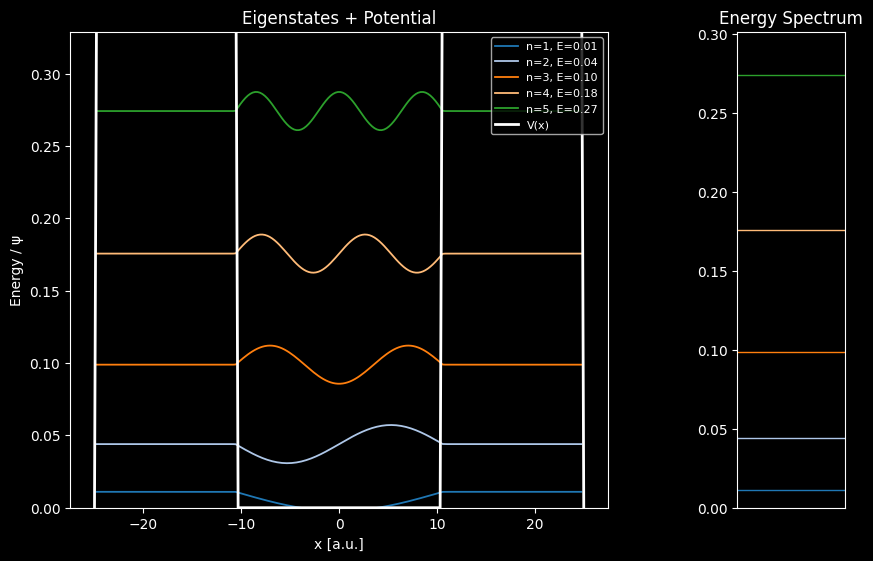

In [ ]:
plot_dead(E=E_vals, psi=psi_vecs, V=V_full, x=x, nos=5);

## Verify Against 
```python 
import QM Solve
```

In [ ]:
from functions import verify_solver

verify_solver()

---
Deploy:


https://huggingface.co/spaces/AhiBucket/Hand-wave



```python

python -m streamlit run app.py
```

In [ ]:
show_QR(url)